## Obtaining the Efficient Frontier - Part III

*Suggested Answers follow (usually there are multiple ways to solve a problem in Python).*

Ok, let’s continue the exercise from the last lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

assets = ['WMT', 'FB']
pf_data = pd.read_csv('Dataset/Walmart_FB_2014_2017.csv', index_col='Date')

In [2]:
log_returns = np.log(pf_data / pf_data.shift(1))

num_assets = len(assets)

weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights

array([0.51343081, 0.48656919])

Now, estimate the expected Portfolio Return, Variance, and Volatility.

Expected Portfolio Return:

In [3]:
np.sum(weights * log_returns.mean()) * 250

np.float64(0.14168213698837653)

Expected Portfolio Variance:

In [4]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

np.float64(0.03230009106030945)

Expected Portfolio Volatility:

In [5]:
np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights)))

np.float64(0.17972226089249335)

***

The rest of this exercise will be a reproduction of what we did in the previous video.

1)	Create two empty lists. Name them pf_returns and pf_volatilites.

In [6]:
pf_returns = []
pf_volatilities = []

2)	Create a loop with 1,000 iterations that will generate random weights, summing to 1, and will append the obtained values for the portfolio returns and the portfolio volatilities to pf_returns and pf_volatilities, respectively.

In [7]:
for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pf_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pf_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))
    
pf_returns, pf_volatilities

([np.float64(0.2254085771527425),
  np.float64(0.01731915885625161),
  np.float64(0.14213783027098204),
  np.float64(0.13124645593331102),
  np.float64(0.08743610945541028),
  np.float64(0.24331561085472783),
  np.float64(0.09727405060197408),
  np.float64(0.05951334346781193),
  np.float64(0.11269306717438034),
  np.float64(0.11798679035384854),
  np.float64(0.18433181802745072),
  np.float64(0.07079398971669695),
  np.float64(0.20834551707857513),
  np.float64(0.1065810654001994),
  np.float64(0.16975012564153963),
  np.float64(0.28244079276668377),
  np.float64(0.13626966382554867),
  np.float64(0.12371360431435145),
  np.float64(0.15921812359405055),
  np.float64(0.14988787080087856),
  np.float64(0.2191934141281082),
  np.float64(0.05901155743971632),
  np.float64(0.06394720821833867),
  np.float64(0.19410130599769493),
  np.float64(0.05219637065526716),
  np.float64(0.03352684436234296),
  np.float64(0.19013014317684707),
  np.float64(0.09761701541577075),
  np.float64(0.17782192

3)	Transform the obtained lists into NumPy arrays and reassign them to pf_returns and pf_volatilites. Once you have done that, the two objects will be NumPy arrays. 

In [8]:
pf_returns = np.array(pf_returns)
pf_volatilities = np.array(pf_volatilities)

pf_returns, pf_volatilities

(array([0.22540858, 0.01731916, 0.14213783, 0.13124646, 0.08743611,
        0.24331561, 0.09727405, 0.05951334, 0.11269307, 0.11798679,
        0.18433182, 0.07079399, 0.20834552, 0.10658107, 0.16975013,
        0.28244079, 0.13626966, 0.1237136 , 0.15921812, 0.14988787,
        0.21919341, 0.05901156, 0.06394721, 0.19410131, 0.05219637,
        0.03352684, 0.19013014, 0.09761702, 0.17782192, 0.21339127,
        0.12032832, 0.28268845, 0.12591787, 0.1774168 , 0.13107322,
        0.13024345, 0.09215883, 0.18078186, 0.18556941, 0.1190768 ,
        0.13357362, 0.09777287, 0.27436845, 0.02979018, 0.14181279,
        0.03947889, 0.13381916, 0.1359456 , 0.10471059, 0.10369794,
        0.13156217, 0.11212773, 0.28598519, 0.12297434, 0.2471486 ,
        0.17179093, 0.17412731, 0.07052648, 0.14176833, 0.19087502,
        0.09992139, 0.0103409 , 0.19614148, 0.2356936 , 0.16891701,
        0.08033732, 0.00888767, 0.11559021, 0.12121301, 0.19373151,
        0.15901801, 0.16091069, 0.08513073, 0.26

Now, create a dictionary, called portfolios, whose keys are the strings “Return” and “Volatility” and whose values are the NumPy arrays pf_returns and pf_volatilities. 

In [9]:
portfolios = pd.DataFrame({'Return': pf_returns, 'Volatility': pf_volatilities})

Finally, plot the data from the portfolios dictionary on a graph. Let the x-axis represent the volatility data from the portfolios dictionary and the y-axis – the data about rates of return. <br />
Organize your chart well and make sure you have labeled both the x- and the y- axes.

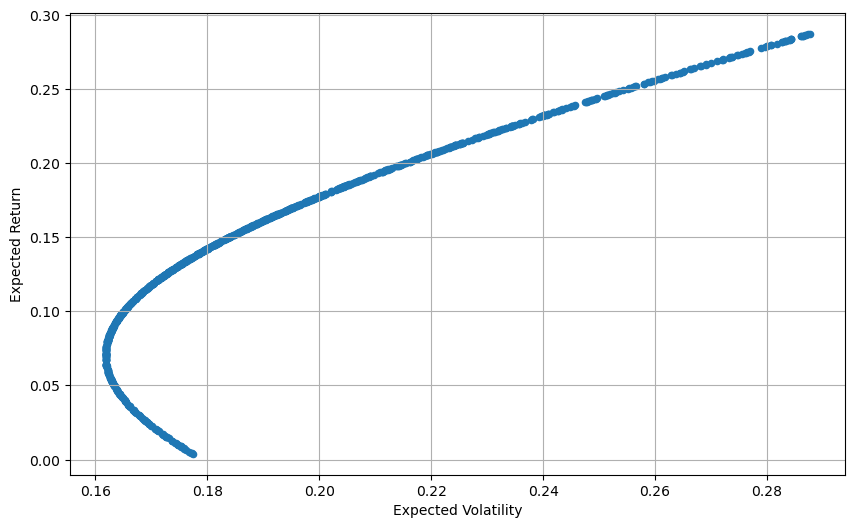

In [10]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10,6), grid=True)
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.show()

******

What do you think would happen if you re-created the Markowitz Efficient Frontier for 3 stocks? The code you have created is supposed to accommodate easily the addition of a third stock, say British Petroleum (‘BP’). Insert it in your data and re-run the code (you can expand the “Cell” list from the Jupyter menu and click on “Run All” to execute all the cells at once!). <br />

How would you interpret the obtained graph? 


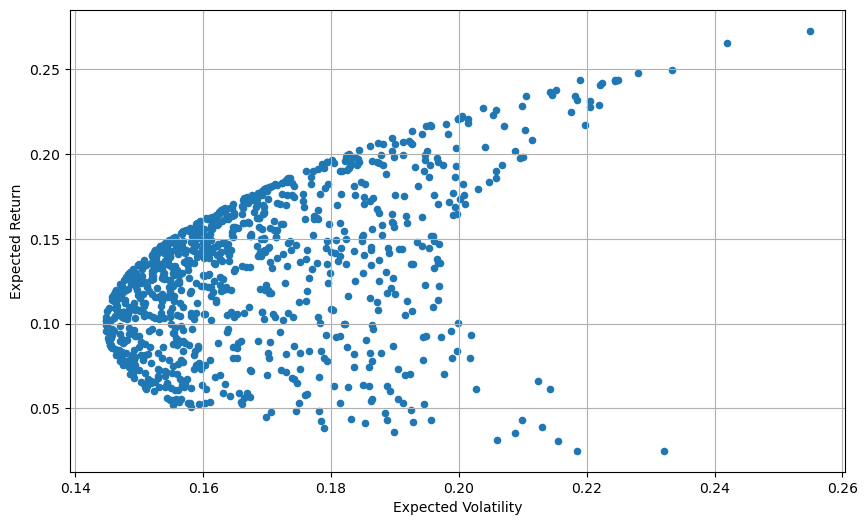

: 

In [ ]:
assets = ['WMT', 'FB', 'BP']
num_assets = len(assets)

pf_data = pd.read_csv('Dataset/WMT_FB_BP_2014_2017.csv', index_col='Date')

log_returns = np.log(pf_data / pf_data.shift(1))

#weights = np.random.random(num_assets)
#weights /= np.sum(weights)
#exp_return = np.sum(weights * log_returns.mean()) * 250
#exp_volatility = np.sqrt(np.dot(weights.T,np.dot(log_returns.cov()*250, weights)))

pf_returns = []
pf_volatilities = []

for x in range (1000):
    # Create random weights
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    # Add the values of the returns and volatilities with the random weights
    pf_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pf_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov()*250, weights))))

# Convert the lists in numpy arrays for easier manipulations
pf_returns = np.array(pf_returns)
pf_volatilities = np.array(pf_volatilities)

portfolios = pd.DataFrame({'Return': pf_returns, 'Volatility': pf_volatilities})

portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10,6), grid=True)
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.show()


Expected Portfolio Return:

Expected Portfolio Variance:

Expected Portfolio Volatility:

*****

In [14]:
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10, 6));
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')

Text(0, 0.5, 'Expected Return')